# Customer Segmentation for CLV and RFM

In [1]:
# import relevant libraries

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

## Executive Summary

[Company] is looking to improve targeting campaigns, identifying customer behavior, and efficiency in customer communication, so I was tasked with clustering customers into identifiable groups that can be targeted with marketing campaigns related to that customer type. Using predominantly Python libraries (Numpy, Seaborn, Pandas, Matplotlib, sklearn), I pulled the data from CSV files, cleaned the data, engineered data columns for important metrics, performed data analysis using customer metrics, and visualized the groupings of customers across metrics. 

## Business Problem

Average gross revenue from individual customers needs to be observed in order to identify possible optimization points. How can we determine which users are the most likely to spend and how should we contact them to increase the gross revenue from individuals?

### Feature Engineering: CLV

First, need to get the data on customers that signed up for the loyalty program, campaigns used, products hald, and transactions/events occurred.

In [2]:
# import relevant datasets

campaigns = pd.read_csv(r'C:\Users\Tangy\Downloads\archive (2)\campaigns_idf.csv')
customers = pd.read_csv(r'C:\Users\Tangy\Downloads\archive (2)\customers_idf.csv')
products = pd.read_csv(r'C:\Users\Tangy\Downloads\archive (2)\products_idf.csv')
transactions = pd.read_csv(r'C:\Users\Tangy\Downloads\archive (2)\transactions_idf.csv')
events = pd.read_csv(r'C:\Users\Tangy\Downloads\archive (2)\events_idf.csv')

# change data types on dates so they can be used
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
transactions['timestamp'] = pd.to_datetime(transactions['timestamp'])
events['timestamp'] = pd.to_datetime(events['timestamp'])

Next, in order to compare customers and see how the contribute to gross revenue, we observe some general metrics on gross revenue per individual, how recently they purchased items, and how often they purchase. I use these metrics to calculate Customer Lifetime Value (CLV) to get a centralized comparison of how much individual customers contribute. 

In [3]:
# customer metrics coloumns

customer_metrics = transactions.groupby('customer_id').agg({
        'gross_revenue': ['sum', 'mean', 'count'],
        'timestamp': ['min', 'max']
    }).round(2)
customer_metrics.columns = ['total_revenue', 'avg_order_value', 'frequency', 'first_purchase', 'last_purchase']
customer_metrics = customer_metrics.reset_index()

last_entry = transactions['timestamp'].max()
customer_metrics['recency'] = (last_entry - customer_metrics['last_purchase']).dt.days

customer_metrics['lifespan_days'] = (customer_metrics['last_purchase'] - customer_metrics['first_purchase']).dt.days + 1
customer_metrics = customer_metrics.merge(customers, on='customer_id', how='left')

In [4]:
# calculate clv using simple formula: average order value * frequency * gross margin (assumed 20%) * predicted lifespan
# predicted lifespan based on current behavior pattern
customer_metrics['predicted_lifespan_years'] = np.where(
    customer_metrics['frequency'] > 1,
    customer_metrics['lifespan_days'] / customer_metrics['frequency'] * 0.01,  # Scale factor
    0.5  # default for single-purchase customers
)

customer_metrics['clv'] = (
    customer_metrics['avg_order_value'] * 
    customer_metrics['frequency'] * 
    0.2 *  
    customer_metrics['predicted_lifespan_years']
).round(2)

### Feature Engineering: RFM

"RFM" stands for Recency, Frequency, and Monetary, referring to the metrics by the same name and is used to gauge the interactivity of a customer. In the previous section, I established the recency, frequency, and gross revenue metircs in accordance with this principle, now I will develop a combined score based on standard market practices to identify and break customers into groups by interactivity. 

In [6]:
# establishment of ranks
customer_metrics['R_rank'] = customer_metrics['recency'].rank(ascending=False)
customer_metrics['F_rank'] = customer_metrics['frequency'].rank(ascending=True)
customer_metrics['M_rank'] = customer_metrics['total_revenue'].rank(ascending=True)

# normalization of ranks
customer_metrics['R_rank_norm'] = (customer_metrics['R_rank'] / customer_metrics['R_rank'].max()) * 100
customer_metrics['F_rank_norm'] = (customer_metrics['F_rank'] / customer_metrics['F_rank'].max()) * 100
customer_metrics['M_rank_norm'] = (customer_metrics['M_rank'] / customer_metrics['M_rank'].max()) * 100

# drop non-normalized columns
customer_metrics.drop(columns=['R_rank', 'F_rank', 'M_rank'], inplace=True)

# overall rfm score; values are based on business needs but are somewhat arbitrary; a customers total monetary contribution was deemed the most important
#  and thus given the highest weight, then frequency, then recency
customer_metrics['RFM_Score'] = 0.15 * customer_metrics['R_rank_norm'] + 0.28 * customer_metrics['F_rank_norm'] + 0.57 * customer_metrics['M_rank_norm']
customer_metrics['RFM_Score'] *= 0.05
customer_metrics = customer_metrics.round(2)

# establishment of RFM score type so we know how to appeal to who; the ranges are also somewhat arbitrary
customer_metrics["Customer_segment"] = np.where(customer_metrics['RFM_Score'] > 4.5, "Top Customers",
                                       np.where(customer_metrics['RFM_Score'] > 4, "High value Customer",
                                                np.where(customer_metrics['RFM_Score'] > 3, "Medium Value Customer",
                                                         np.where(customer_metrics['RFM_Score'] > 1.6, 'Low Value Customers', 'Lost Customers'))))

customer_metrics.head()

,customer_id,total_revenue,avg_order_value,frequency,first_purchase,last_purchase,recency,lifespan_days,signup_date,country,...,gender,loyalty_tier,acquisition_channel,predicted_lifespan_years,clv,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score,Customer_segment
0,2,60.09,60.09,1,2021-01-30 06:32:34,2021-01-30 06:32:34,1065,1,2023-04-28,IN,...,Female,Silver,Organic,0.50,6.01,1.55,28.68,35.24,1.42,Lost Customers
1,8,65.25,65.25,1,2023-11-19 07:55:42,2023-11-19 07:55:42,42,1,2023-02-03,US,...,Male,Bronze,Organic,0.50,6.52,92.48,28.68,37.64,2.17,Low Value Customers
2,9,65.63,65.63,1,2022-04-06 23:00:15,2022-04-06 23:00:15,633,1,2021-08-09,BR,...,Female,Bronze,Paid Search,0.50,6.56,29.96,28.68,37.79,1.70,Low Value Customers
3,13,71.90,35.95,2,2021-12-01 12:53:17,2022-08-31 08:52:51,487,273,2023-03-17,US,...,Male,Gold,Organic,1.36,19.63,41.80,71.77,40.86,2.48,Low Value Customers
4,14,76.14,76.14,1,2022-06-22 12:48:33,2022-06-22 12:48:33,557,1,2023-04-14,IN,...,Male,Silver,Paid Search,0.50,7.61,36.00,28.68,43.01,1.90,Low Value Customers


### Customer Clustering: CLV

We can find the best groups of customers to appeal to using CLV by clustering the customers by CLV, finding the best number of groups that fits the dataset, then selecting the cluster that provides the most people with a high CLV. 

In [7]:
# iterate through different cluster amounts to get the optimal number of clusters that fits the dataset
# the inertia value is used to define the average distance between points in a cluster, and as such can be used to find clusters that
#  have the closest values/contain the most similar data. Note that most of the values are rather high, which indicates most of the clusters have
#  a large average distance between points, which indicates the clusters are not compact

inertia_scores = []
for i in range(1, 11):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(customer_metrics[['clv']])
    inertia_scores.append(kmeans.inertia_)
print(inertia_scores)

[244112050.42798978, 89399112.66750388, 48226756.81328818, 30854293.518853355, 22137932.41049204, 17059394.31321065, 13408866.427591346, 11324345.817884615, 9873608.889513317, 8013153.968714495]


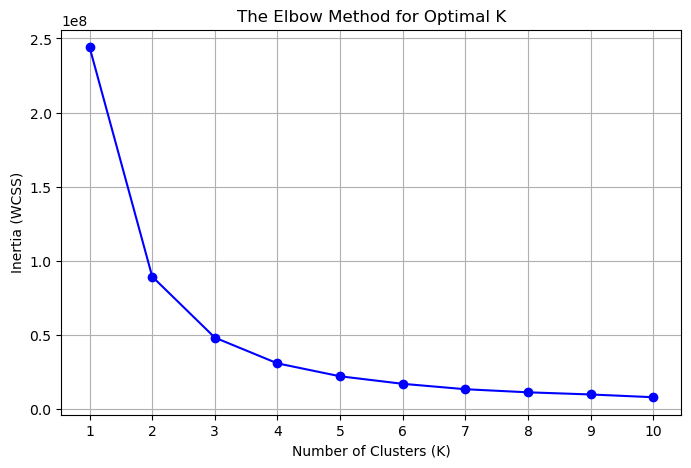

In [8]:
# I then plot the values optained through the iterations and find the "elbow" of the graph; the "elbow" is the point at which there is the most change
#  from the decrease in scores, such that I have the best ratio of inertia score to number of clusters
# While the clusters are not compact, they show a clear "elbow curve" and the optimal number of clusters is identifiable; this means the method is liekly
#  still viable to identify customer groups by this metric

plt.figure(figsize=(8, 5))
plt.plot(range(1,11), inertia_scores, marker='o', linestyle='-', color='b')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(range(1,11))
plt.grid(True)
plt.show()

In [9]:
# The optimal number of clusters from the iterations is about 3, as evident by the graph, so we put that as out final clustering method for use later

c1 = KMeans(n_clusters=3)
c1.fit(customer_metrics[['clv']])

customer_metrics['CLV Cluster'] = c1.labels_
# print(customer_metrics['CLV Cluster'].value_counts())

<Axes: xlabel='clv', ylabel='age'>

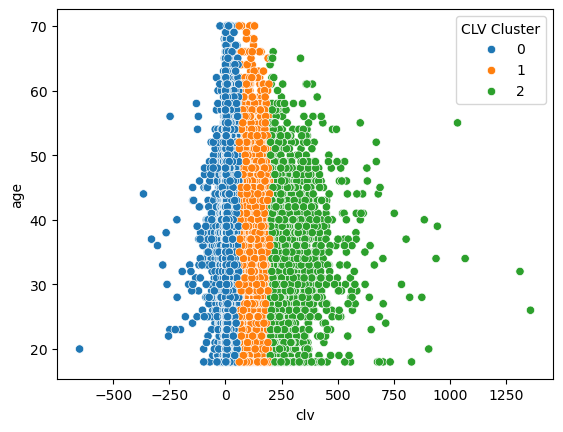

In [10]:
sns.scatterplot(data=customer_metrics, x='clv', y='age', hue='CLV Cluster', palette='tab10')

### Customer Clustering: RFM

We can also use the RFM metric to determine the best group of customers to appeal to. 

In [11]:
inertia_scores3 = []
for i in range(1, 11):
    kmeans3=KMeans(n_clusters=i)
    kmeans3.fit(customer_metrics[['RFM_Score']])
    inertia_scores3.append(kmeans3.inertia_)
print(inertia_scores3)

[81060.12644326416, 21210.22169049415, 9916.747308817377, 5691.483994895824, 3737.4139704896393, 2653.532831897854, 1980.5857341486403, 1526.4775553871996, 1197.5261645620226, 973.6674762619118]


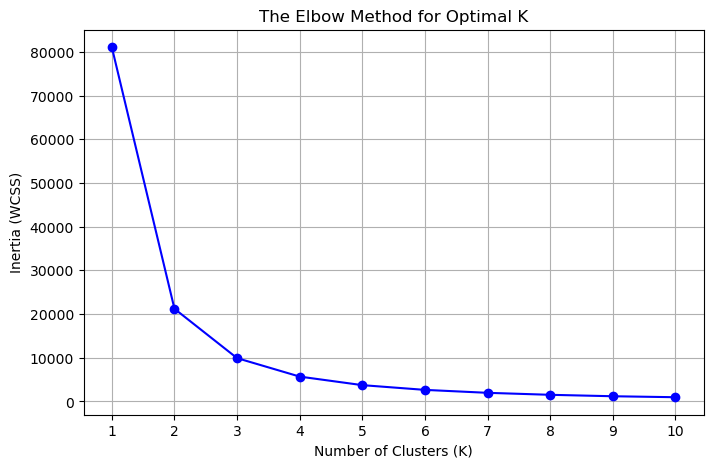

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(1,11), inertia_scores3, marker='o', linestyle='-', color='b')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(range(1,11))
plt.grid(True)
plt.show()

In [13]:
# The optimal number of clusters from the iterations is about 3, as evident by the graph, so we put that as out final clustering method for use later

c2 = KMeans(n_clusters=3)
c2.fit(customer_metrics[['RFM_Score']])

customer_metrics['RFM Cluster'] = c1.labels_
customer_metrics.head()

,customer_id,total_revenue,avg_order_value,frequency,first_purchase,last_purchase,recency,lifespan_days,signup_date,country,...,acquisition_channel,predicted_lifespan_years,clv,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score,Customer_segment,CLV Cluster,RFM Cluster
0,2,60.09,60.09,1,2021-01-30 06:32:34,2021-01-30 06:32:34,1065,1,2023-04-28,IN,...,Organic,0.50,6.01,1.55,28.68,35.24,1.42,Lost Customers,0,0
1,8,65.25,65.25,1,2023-11-19 07:55:42,2023-11-19 07:55:42,42,1,2023-02-03,US,...,Organic,0.50,6.52,92.48,28.68,37.64,2.17,Low Value Customers,0,0
2,9,65.63,65.63,1,2022-04-06 23:00:15,2022-04-06 23:00:15,633,1,2021-08-09,BR,...,Paid Search,0.50,6.56,29.96,28.68,37.79,1.70,Low Value Customers,0,0
3,13,71.90,35.95,2,2021-12-01 12:53:17,2022-08-31 08:52:51,487,273,2023-03-17,US,...,Organic,1.36,19.63,41.80,71.77,40.86,2.48,Low Value Customers,0,0
4,14,76.14,76.14,1,2022-06-22 12:48:33,2022-06-22 12:48:33,557,1,2023-04-14,IN,...,Paid Search,0.50,7.61,36.00,28.68,43.01,1.90,Low Value Customers,0,0


In [14]:
customer_metrics.groupby('RFM Cluster')['RFM_Score'].mean()

RFM Cluster
0    2.149796
1    3.962150
2    4.452224
Name: RFM_Score, dtype: float64

## Results

I found clear separations of groups among CLV/RFM values and compared them to other metrics to identify if there appears to be any correlations between identifiable characteristics of the customers and a corresponding revenue contribution. 

Text(0, 0.5, 'Average RFM Cluster')

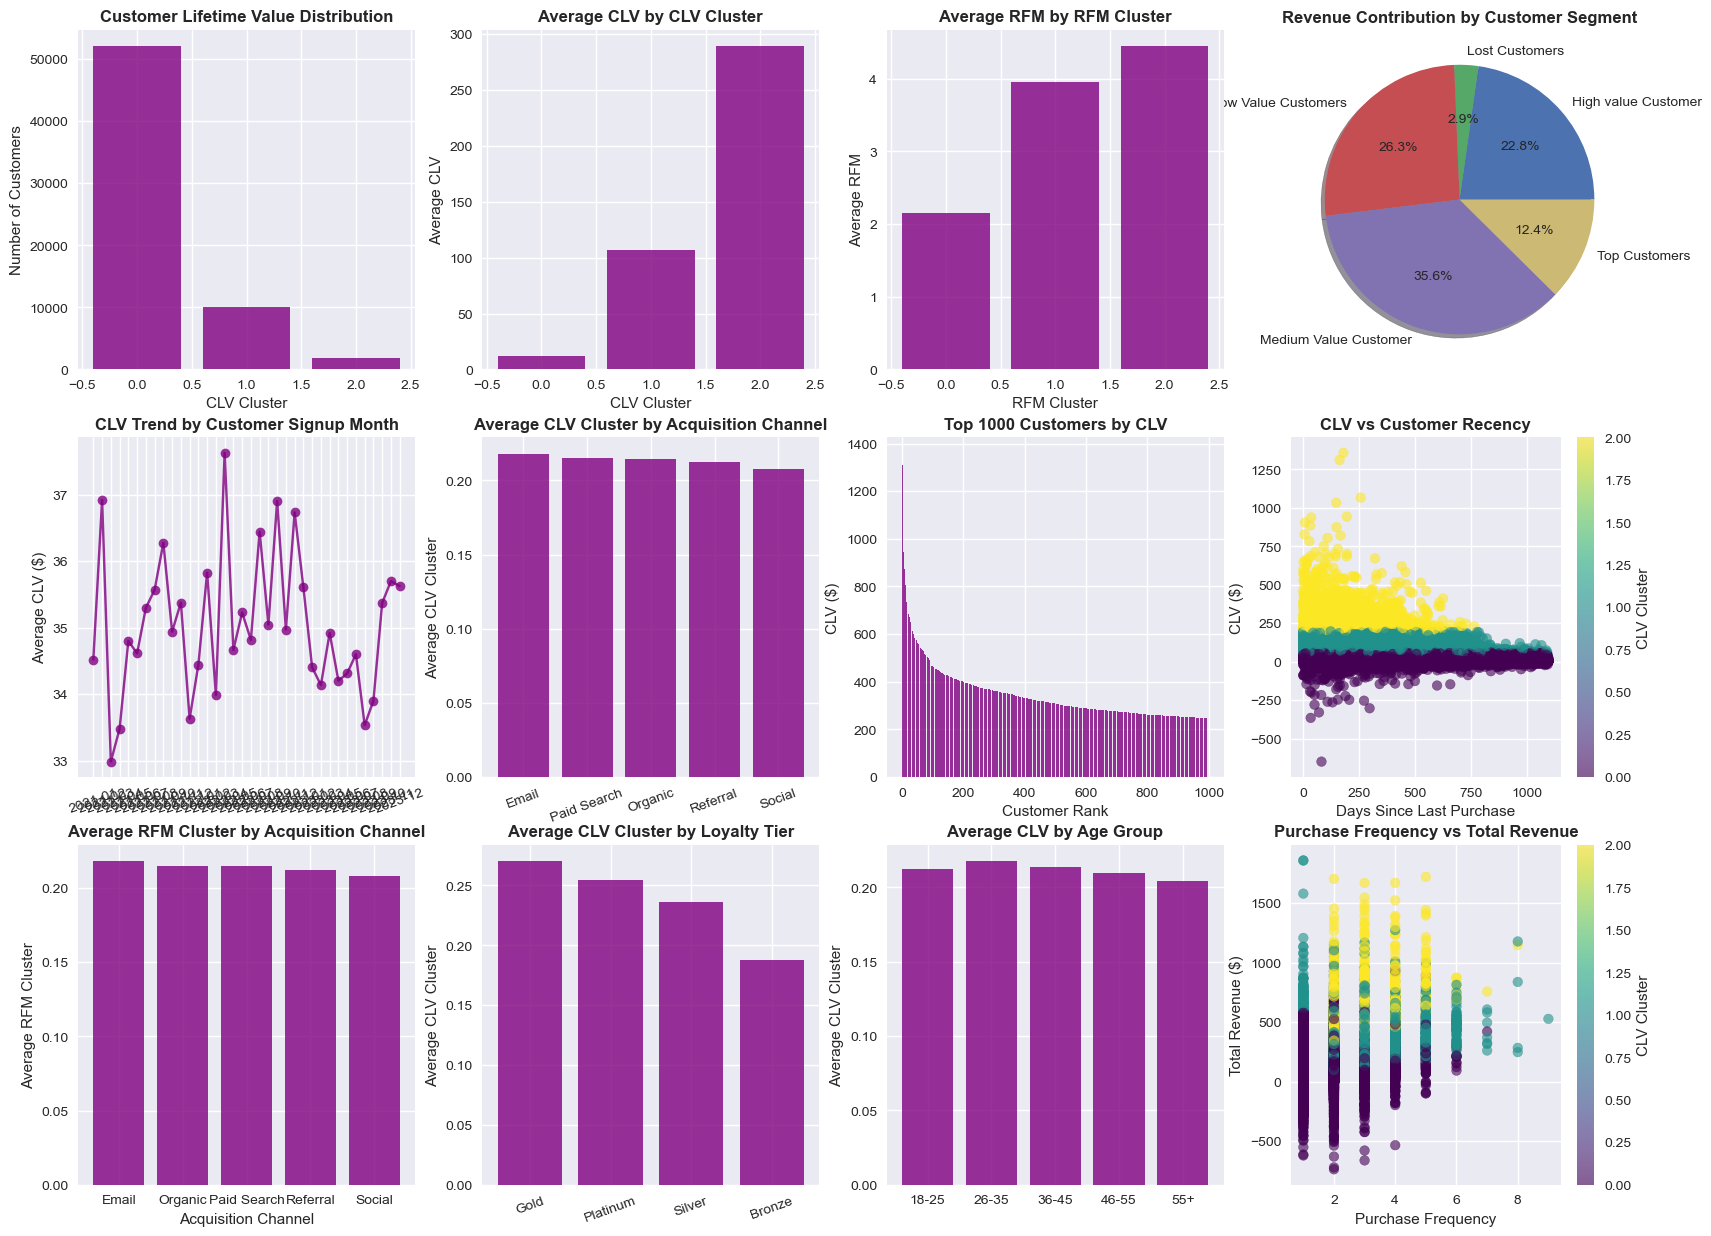

In [72]:
plt.style.use('seaborn-v0_8')
fig = plt.figure(figsize=(20, 15))

# 1. CLV Cluster Distribution
plt.subplot(3, 4, 1)
clv_clusters = customer_metrics.groupby('CLV Cluster')['CLV Cluster'].count()
plt.bar(clv_clusters.index, clv_clusters.values, color='purple', alpha=0.8)
plt.title('Customer Lifetime Value Distribution', fontsize=12, fontweight='bold')
plt.xlabel('CLV Cluster')
plt.ylabel('Number of Customers')

# 2. Average CLV Cluster by Loyalty Tier
plt.subplot(3, 4, 10)
clv_by_tier = customer_metrics.groupby('loyalty_tier')['CLV Cluster'].mean().sort_values(ascending=False)
bars = plt.bar(clv_by_tier.index, clv_by_tier.values, color='purple', alpha=0.8)
plt.title('Average CLV Cluster by Loyalty Tier', fontsize=12, fontweight='bold')
plt.ylabel('Average CLV Cluster')
plt.xticks(rotation=20)

# 3. CLV by Age Group
plt.subplot(3, 4, 11)
customer_metrics['age_group'] = pd.cut(customer_metrics['age'], 
                                     bins=[0, 25, 35, 45, 55, 100], 
                                     labels=['18-25', '26-35', '36-45', '46-55', '55+'])
clv_by_age = customer_metrics.groupby('age_group', observed=False)['CLV Cluster'].mean()
plt.bar(clv_by_age.index, clv_by_age.values, color='purple', alpha=0.8)
plt.title('Average CLV by Age Group', fontsize=12, fontweight='bold')
plt.ylabel('Average CLV Cluster')

# 4. Frequency vs Monetary scatter
plt.subplot(3, 4, 12)
plt.scatter(customer_metrics['frequency'], customer_metrics['total_revenue'], 
            c=customer_metrics['CLV Cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(label='CLV Cluster')
plt.title('Purchase Frequency vs Total Revenue', fontsize=12, fontweight='bold')
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Revenue ($)')

# 5. CLV vs Recency
plt.subplot(3, 4, 8)
plt.scatter(customer_metrics['recency'], customer_metrics['clv'], c=customer_metrics['CLV Cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(label='CLV Cluster')
plt.title('CLV vs Customer Recency', fontsize=12, fontweight='bold')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('CLV ($)')

# 6. Average CLV Cluster by Acquisition Channel
plt.subplot(3, 4, 6)
clv_by_channel = customer_metrics.groupby('acquisition_channel')['CLV Cluster'].mean().sort_values(ascending=False)
plt.bar(clv_by_channel.index, clv_by_channel.values, color='purple', alpha=0.8)
plt.title('Average CLV Cluster by Acquisition Channel', fontsize=12, fontweight='bold')
plt.ylabel('Average CLV Cluster')
plt.xticks(rotation=20)

# 7. Top 1000 Customers by CLV
plt.subplot(3, 4, 7)
top_clv = customer_metrics['clv'].sort_values(ascending=False).nlargest(1000)
plt.bar(range(len(top_clv)), top_clv, color='purple', alpha=0.8)
plt.title('Top 1000 Customers by CLV', fontsize=12, fontweight='bold')
plt.ylabel('CLV ($)')
plt.xlabel('Customer Rank')

# 8. CLV Trend by Signup Date
plt.subplot(3, 4, 5)
customer_metrics['signup_month'] = customer_metrics['signup_date'].dt.to_period('M')
clv_trend = customer_metrics.groupby('signup_month')['clv'].mean()
plt.plot(clv_trend.index.astype(str), clv_trend.values, marker='o', color='purple', alpha=0.8)
plt.title('CLV Trend by Customer Signup Month', fontsize=12, fontweight='bold')
plt.ylabel('Average CLV ($)')
plt.xticks(rotation=20)

# 9. Revenue Contribution by Customer Segment
plt.subplot(3, 4, 4)
rfm_cont = customer_metrics.groupby("Customer_segment")["total_revenue"].sum()
plt.pie(rfm_cont, labels=rfm_count.index, autopct='%1.1f%%', shadow = True)
plt.title('Revenue Contribution by Customer Segment', fontsize=12, fontweight='bold')

# 10. Average CLV by CLV Cluster
plt.subplot(3, 4, 2)
clv_cclus = customer_metrics.groupby('CLV Cluster')['clv'].mean()
plt.bar(clv_cclus.index, clv_cclus.values, color='purple', alpha=0.8)
plt.title('Average CLV by CLV Cluster', fontsize=12, fontweight='bold')
plt.xlabel('CLV Cluster')
plt.ylabel('Average CLV')

# 11. Average RFM Score by RFM Cluster
plt.subplot(3, 4, 3)
rfm_cclus = customer_metrics.groupby('RFM Cluster')['RFM_Score'].mean()
plt.bar(rfm_cclus.index, rfm_cclus.values, color='purple', alpha=0.8)
plt.title('Average RFM by RFM Cluster', fontsize=12, fontweight='bold')
plt.xlabel('RFM Cluster')
plt.ylabel('Average RFM')

# 12. Average RFM Cluster by Acquisition Channel
plt.subplot(3, 4, 9)
rfm_acq = customer_metrics.groupby('acquisition_channel')['RFM Cluster'].mean()
plt.bar(rfm_acq.index, rfm_acq.values, color='purple', alpha=0.8)
plt.title('Average RFM Cluster by Acquisition Channel', fontsize=12, fontweight='bold')
plt.xlabel('Acquisition Channel')
plt.ylabel('Average RFM Cluster')

From these graphs, it seems that the vast majority of customers contibute only a bit of the overall revenue, where as medium to top customers contribute the most (around 70%). The falloff from the highest CLV customers to the lower end happens similar to an exponential curve, enforcing the notion that appealing to the highest value customers is more important than retaining lower CLV customers. For loyalty tiers, while Gold and Platinum had higher CLV averages than Bronze and Silver, their average CLV was not significantly higher, meaning that getting customers to sign up for the loyalty program is likely more important than encouraging a higher tier. 

Clustering CLV and RFM found groups of customers split into high, medium, and low groups with the respective scores, with the CLV clusters having more distinct averages. CLV clusters were used in the final visualization to display how the metric compared, where a low average is indicative of a high presence of customers from the "low" CLV cluster (Cluster 0); this is also true for graphs using the RFM clusters. 

There does not appear to be significant advantages to appealing to certain age groups nor using specific acquisition channels. 